In [57]:
import numpy as np
import pandas as pd

In [58]:
df = pd.read_csv("global_movies_dataset_1950_2026.csv")

In [59]:
df.head()

,movie_id,title,release_year,decade,runtime_min,genre,subgenre,director,lead_actor,lead_actress,...,roi_pct,popularity_score,metascore,audience_score,streaming_platform,award_nominations,award_wins,top_100_prob,blockbuster_flag,franchise_flag
0,1,Crimson Code,2001,2000,116,Action|Drama|Sci-Fi,Superhero,Denis Villeneuve,Brad Pitt,Tom Hanks,...,98.0,82.54,60,74,Netflix,3,2,0.560,0,0
1,2,Lost Empire,1951,1950,85,Crime|Animation,Gangster,Christopher Nolan,Scarlett Johansson,Brad Pitt,...,139.3,80.54,64,56,MGM+,0,0,0.549,0,0
2,3,Last Legacy,1990,1990,141,Sci-Fi|Drama,Cyberpunk,Bong Joon-ho,Emma Stone,Brad Pitt,...,-45.5,81.98,59,60,Peacock,1,1,0.520,0,0
3,4,Crimson River,1952,1950,82,Mystery|Romance,Whodunit,Quentin Tarantino,Meryl Streep,Tom Hanks,...,57.4,72.10,69,77,Disney+,1,1,0.498,0,0
4,5,Lost Dream,2011,2010,130,Romance,Romantic Drama,Quentin Tarantino,Robert Downey Jr.,Timothee Chalamet,...,97.8,60.63,48,57,Prime Video,0,0,0.435,0,0


In [60]:
df.shape

(100000, 27)

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   movie_id                  100000 non-null  int64  
 1   title                     100000 non-null  str    
 2   release_year              100000 non-null  int64  
 3   decade                    100000 non-null  int64  
 4   runtime_min               100000 non-null  int64  
 5   genre                     100000 non-null  str    
 6   subgenre                  100000 non-null  str    
 7   director                  100000 non-null  str    
 8   lead_actor                100000 non-null  str    
 9   lead_actress              100000 non-null  str    
 10  country                   100000 non-null  str    
 11  language                  100000 non-null  str    
 12  imdb_rating               100000 non-null  float64
 13  votes                     100000 non-null  int64  
 14  

In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
movie_id,100000.0,50000.500000,28867.657797,1.000,25000.750,50000.500,75000.2500,100000.00
release_year,100000.0,1988.013390,22.217453,1950.000,1969.000,1988.000,2007.0000,2026.00
decade,100000.0,1983.640400,22.274525,1950.000,1960.000,1980.000,2000.0000,2020.00
runtime_min,100000.0,113.712660,20.218836,70.000,100.000,114.000,127.0000,205.00
imdb_rating,100000.0,6.736212,1.014200,2.200,6.100,6.700,7.4000,9.80
votes,100000.0,40204.260940,52127.491206,425.000,12440.000,24305.000,47767.2500,1539859.00
budget_million,100000.0,48.269718,43.584906,0.500,16.070,34.860,68.0000,284.42
marketing_budget_million,100000.0,22.966829,24.086906,0.100,6.320,14.960,31.0100,180.00
revenue_million,100000.0,133.313829,196.396971,0.060,24.420,66.145,159.5625,2940.58
roi_pct,100000.0,176.872003,238.856193,-90.000,14.800,100.900,253.9250,1100.60


In [63]:
df.isna().sum()

movie_id                    0
title                       0
release_year                0
decade                      0
runtime_min                 0
genre                       0
subgenre                    0
director                    0
lead_actor                  0
lead_actress                0
country                     0
language                    0
imdb_rating                 0
votes                       0
budget_million              0
marketing_budget_million    0
revenue_million             0
roi_pct                     0
popularity_score            0
metascore                   0
audience_score              0
streaming_platform          0
award_nominations           0
award_wins                  0
top_100_prob                0
blockbuster_flag            0
franchise_flag              0
dtype: int64

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



Q1
Does a higher budget lead to greater box office revenue?

In [65]:
correlation = round(df["budget_million"].corr(df["revenue_million"]), 3)
print("Relation_budget_million_&_revenue_million:", correlation)

Relation_budget_million_&_revenue_million: 0.614


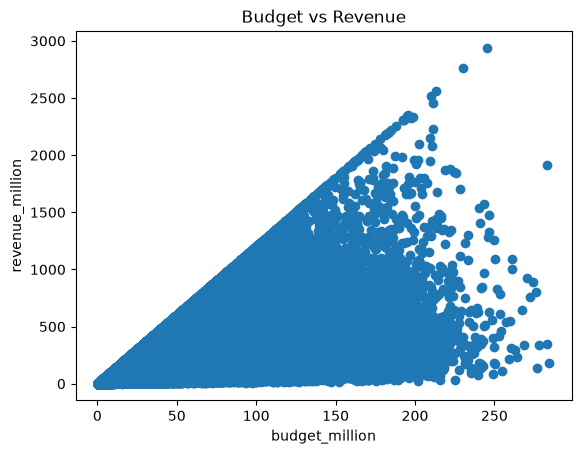

In [66]:
import matplotlib.pyplot as plt

plt.scatter(df["budget_million"], df["revenue_million"])
plt.xlabel("budget_million")
plt.ylabel("revenue_million")
plt.title("Budget vs Revenue")
plt.show()

Key Findings

The correlation of 0.614 confirms a moderate-to-strong positive relationship: as budget increases, revenue tends to increase too.


But the shape of the scatter plot tells a more nuanced story than the correlation number alone:

1.The diagonal upper boundary (that sharp triangular edge)
There's a clear ceiling line running from the bottom-left to the top-right — very few movies exceed roughly 10x their budget in revenue. This diagonal isn't random; it represents the practical maximum return most films can achieve, no matter how good they are.

2.The wide spread below that line — this is the real story
For any given budget level, revenue varies enormously. Look at budget ≈ 150M: revenue ranges from near 0 all the way up to ~2000M for movies at that same budget. This means budget sets the upper limit of what's possible, but doesn't determine the actual outcome.

3.High-budget movies (200M+) show the widest risk
Notice how the spread actually widens at higher budgets — some 250M+ budget films earn 2500M+, while others in that same budget range earn under 200M (a total flop). Bigger budgets don't reduce risk — they amplify the range of possible outcomes (bigger wins, but also bigger losses).

4.Low-budget films cluster near the origin
Films under ~25M budget mostly generate proportionally low revenue too — makes sense, since low budgets usually mean limited theatrical release, less marketing reach, and smaller target audiences.


"There is a moderate-to-strong positive correlation (r = 0.614) between budget and revenue, confirming that higher-budget films generally earn more at the box office. However, the scatter plot reveals a triangular distribution rather than a tight linear relationship: budget appears to set an upper ceiling on potential revenue, but does not guarantee it. Many high-budget films underperform significantly relative to their budget, while budget alone cannot explain why films with similar budgets have vastly different outcomes. This suggests other factors — such as marketing, genre, timing, and audience reception — play a substantial role in determining whether a film reaches its revenue potential."




---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Q2.
Which movie genres generate the highest revenue?

In [68]:

pivot = df.pivot_table(index="genre", values="revenue_million", aggfunc="sum")
pivot_top10 = pivot.sort_values("revenue_million", ascending=False).head(10)
print(pivot_top10)

           revenue_million
genre                     
Sci-Fi           575114.35
Fantasy          554898.72
Adventure        533770.07
Action           485889.55
Animation        423848.06
Thriller         217260.47
Comedy           187349.76
Crime            186211.97
Romance          167477.52
Drama            162833.40


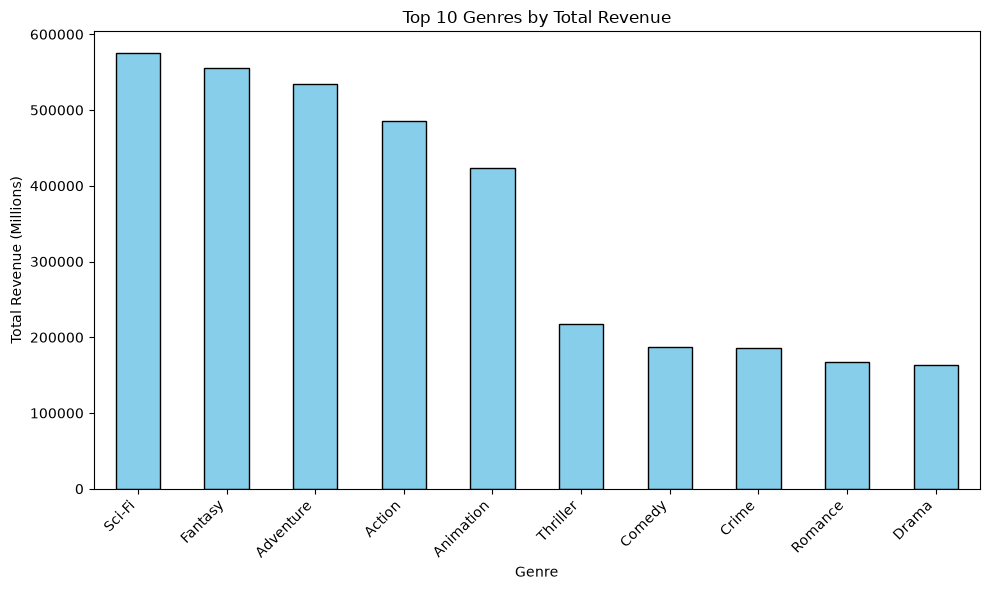

In [69]:
pivot_top10.plot(kind="bar", legend=False, figsize=(10,6), color="skyblue", edgecolor="black")
plt.xlabel("Genre")
plt.ylabel("Total Revenue (Millions)")
plt.title("Top 10 Genres by Total Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



Q3.Is there a relationship between audience ratings and commercial success?


In [70]:
df["profit"] = df["revenue_million"] - df["budget_million"]
df["roi"] = round((df["revenue_million"] - df["budget_million"]) / df["budget_million"],2)

In [71]:
df.head()

,movie_id,title,release_year,decade,runtime_min,genre,subgenre,director,lead_actor,lead_actress,...,metascore,audience_score,streaming_platform,award_nominations,award_wins,top_100_prob,blockbuster_flag,franchise_flag,profit,roi
0,1,Crimson Code,2001,2000,116,Action|Drama|Sci-Fi,Superhero,Denis Villeneuve,Brad Pitt,Tom Hanks,...,60,74,Netflix,3,2,0.560,0,0,54.93,0.98
1,2,Lost Empire,1951,1950,85,Crime|Animation,Gangster,Christopher Nolan,Scarlett Johansson,Brad Pitt,...,64,56,MGM+,0,0,0.549,0,0,63.09,1.39
2,3,Last Legacy,1990,1990,141,Sci-Fi|Drama,Cyberpunk,Bong Joon-ho,Emma Stone,Brad Pitt,...,59,60,Peacock,1,1,0.520,0,0,-27.64,-0.46
3,4,Crimson River,1952,1950,82,Mystery|Romance,Whodunit,Quentin Tarantino,Meryl Streep,Tom Hanks,...,69,77,Disney+,1,1,0.498,0,0,21.31,0.57
4,5,Lost Dream,2011,2010,130,Romance,Romantic Drama,Quentin Tarantino,Robert Downey Jr.,Timothee Chalamet,...,48,57,Prime Video,0,0,0.435,0,0,19.35,0.98


In [72]:
df["roi"].max()

np.float64(11.04)

In [73]:
correlation = round(df["imdb_rating"].corr(df["roi"]), 3)
print("Relation_between_ROI_&_IMDB_Rating:", correlation)

Relation_between_ROI_&_IMDB_Rating: 0.244


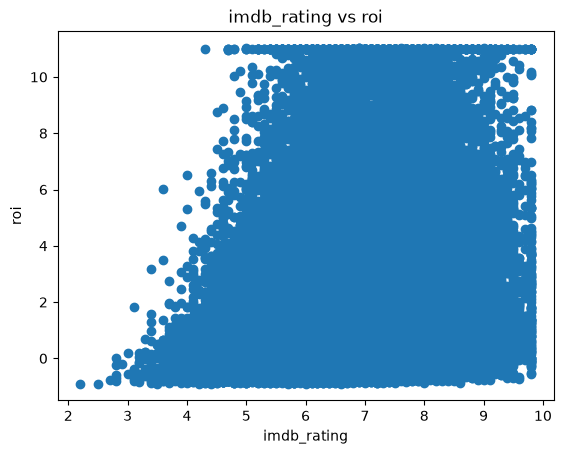

In [74]:

plt.scatter(df["imdb_rating"], df["roi"])
plt.xlabel("imdb_rating")
plt.ylabel("roi")
plt.title("imdb_rating vs roi")
plt.show()

Overall finding: Weak-to-moderate positive relationship
The correlation of 0.244 confirms what the plot shows visually — IMDb rating and ROI are positively related, but the relationship is weak. Rating explains only a small part of why some movies have higher ROI than others; most of the variation in returns comes from other factors (budget size, genre, marketing, franchise status, release timing, etc.), not audience rating alone.



What the shape of the plot tells you (beyond the single correlation number)

Low ratings (2–4): capped downside
Poorly-rated movies cluster tightly near ROI 0 or slightly negative. Very few bad movies achieve high returns — a low rating almost guarantees mediocre-to-poor financial performance.
Mid-to-high ratings (5–10): wide spread
Once a movie crosses roughly rating 5, ROI outcomes become highly unpredictable — some highly-rated movies still lose money, while others achieve very high returns. This is often called a "wedge" or "triangular" relationship.



Key takeaway from the wedge shape:
A good rating does not guarantee commercial success, but a bad rating almost guarantees a movie won't be a big financial hit.


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Q4. Which directors or actors consistently deliver successful movies?




In [80]:
director_stats = df.groupby("director")["revenue_million"].agg(["mean", "std", "count"])
director_stats_filtered = director_stats[director_stats["count"] >= 3]
print(director_stats_filtered.sort_values("std"))

                         mean         std  count
director                                        
Quentin Tarantino  131.646565  190.477447  10053
Steven Spielberg   132.812789  191.326684  10053
Denis Villeneuve   130.644466  191.808408   9909
Christopher Nolan  133.093175  193.314573  10066
Greta Gerwig       131.683975  194.069863  10096
Sofia Coppola      131.822085  196.393235  10037
James Cameron      134.888453  200.793333   9939
Bong Joon-ho       135.346920  201.252710   9899
Martin Scorsese    134.151703  201.310707   9956
Patty Jenkins      137.094837  202.857219   9992


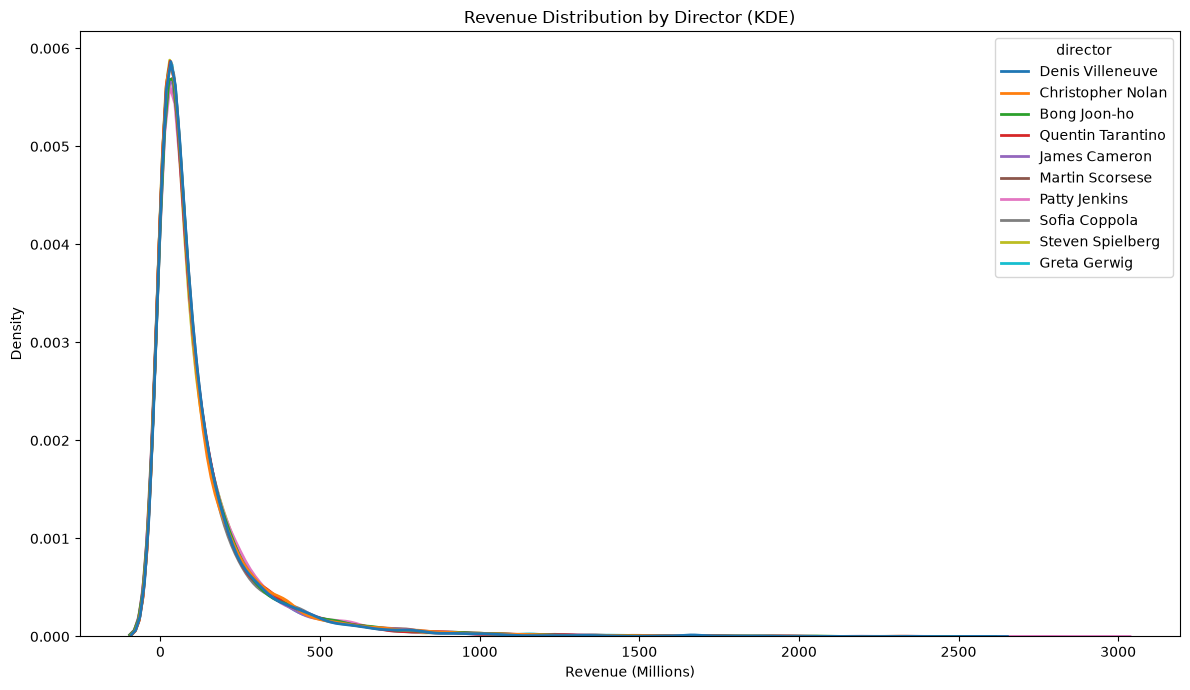

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
sns.kdeplot(data=df, x="revenue_million", hue="director", 
            fill=False, common_norm=False, linewidth=2)
plt.xlabel("Revenue (Millions)")
plt.ylabel("Density")
plt.title("Revenue Distribution by Director (KDE)")
plt.tight_layout()
plt.show()

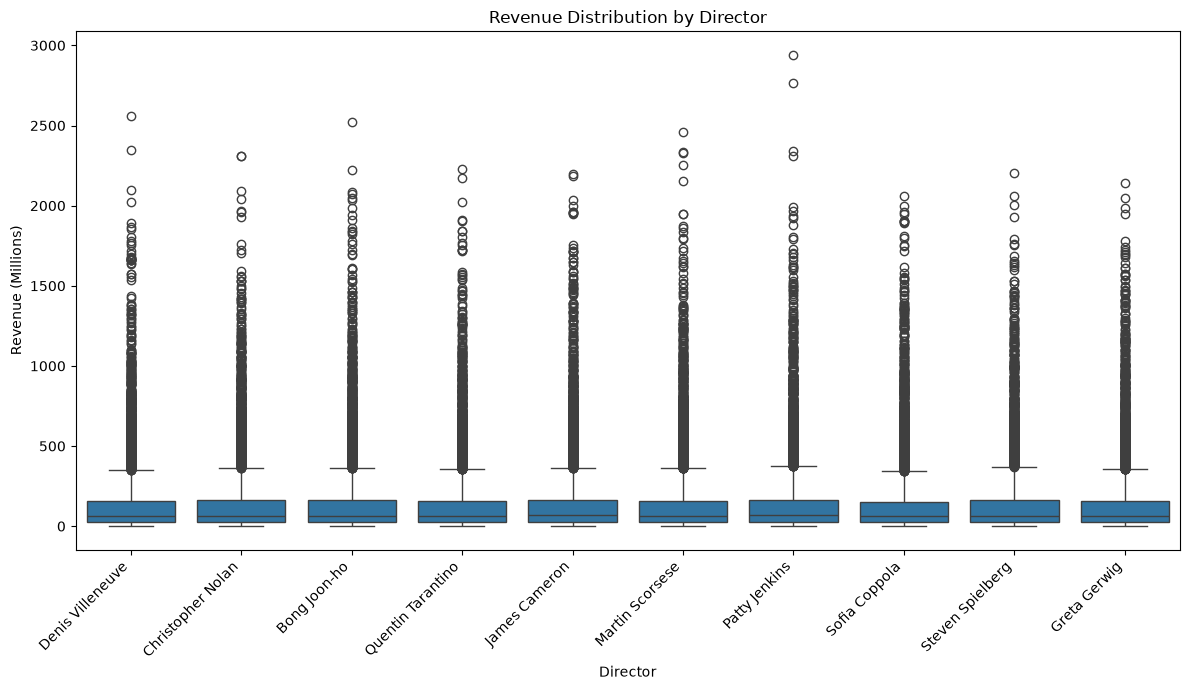

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
sns.boxplot(data=df, x="director", y="revenue_million")
plt.xlabel("Director")
plt.ylabel("Revenue (Millions)")
plt.title("Revenue Distribution by Director")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [93]:
def count_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return len(outliers)

outlier_counts = df.groupby("director")["revenue_million"].apply(count_outliers_iqr)
print(outlier_counts)

director
Bong Joon-ho         869
Christopher Nolan    873
Denis Villeneuve     852
Greta Gerwig         865
James Cameron        848
Martin Scorsese      881
Patty Jenkins        831
Quentin Tarantino    868
Sofia Coppola        926
Steven Spielberg     829
Name: revenue_million, dtype: int64


In [94]:
def cap_outliers_iqr(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return group.clip(lower=lower_bound, upper=upper_bound)

df["revenue_capped"] = df.groupby("director")["revenue_million"].transform(cap_outliers_iqr)

In [96]:
print(df[["director", "revenue_million", "revenue_capped"]].head(10))

# Compare stats before vs after capping
comparison = df.groupby("director").agg(
    mean_before=("revenue_million", "mean"),
    std_before=("revenue_million", "std"),
    mean_after=("revenue_capped", "mean"),
    std_after=("revenue_capped", "std")
)
print(comparison)

            director  revenue_million  revenue_capped
0   Denis Villeneuve           111.00          111.00
1  Christopher Nolan           108.38          108.38
2       Bong Joon-ho            33.07           33.07
3  Quentin Tarantino            58.47           58.47
4  Quentin Tarantino            39.13           39.13
5      James Cameron           186.64          186.64
6   Denis Villeneuve            85.57           85.57
7  Quentin Tarantino           122.34          122.34
8    Martin Scorsese           100.52          100.52
9       Bong Joon-ho             8.73            8.73
                   mean_before  std_before  mean_after   std_after
director                                                          
Bong Joon-ho        135.346920  201.252710  110.416774  112.109225
Christopher Nolan   133.093175  193.314573  110.083576  112.919474
Denis Villeneuve    130.644466  191.808408  107.656813  108.120172
Greta Gerwig        131.683975  194.069863  108.062065  109.590062
Jame

In [98]:
director_summary_sorted = director_summary.sort_values("std_revenue")
director_summary_sorted[["mean_revenue", "std_revenue"]] = director_summary_sorted[["mean_revenue", "std_revenue"]].round(2)
print(director_summary_sorted)


            director  mean_revenue  std_revenue  count
8      Sofia Coppola        106.48       107.63  10037
2   Denis Villeneuve        107.66       108.12   9909
3       Greta Gerwig        108.06       109.59  10096
7  Quentin Tarantino        109.03       110.55  10053
5    Martin Scorsese        108.80       111.41   9956
4      James Cameron        110.21       111.91   9939
0       Bong Joon-ho        110.42       112.11   9899
1  Christopher Nolan        110.08       112.92  10066
9   Steven Spielberg        110.94       113.97  10053
6      Patty Jenkins        113.07       115.16   9992


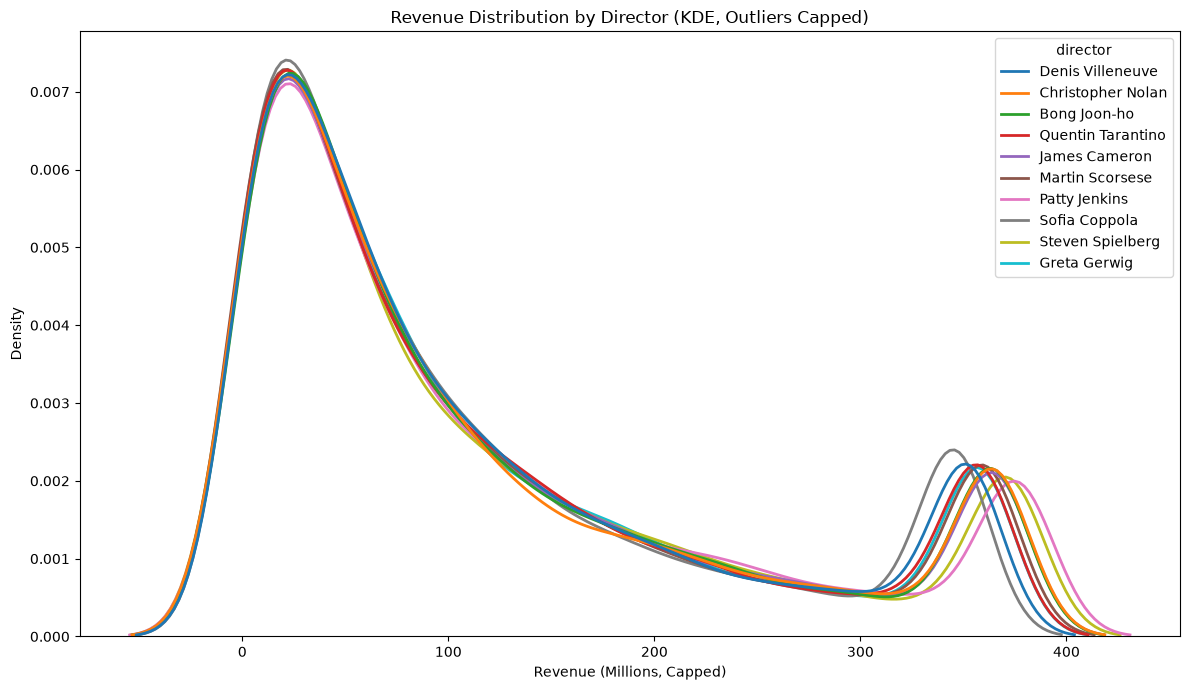

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
sns.kdeplot(data=df, x="revenue_capped", hue="director", 
            fill=False, common_norm=False, linewidth=2)
plt.xlabel("Revenue (Millions, Capped)")
plt.ylabel("Density")
plt.title("Revenue Distribution by Director (KDE, Outliers Capped)")
plt.tight_layout()
plt.show()

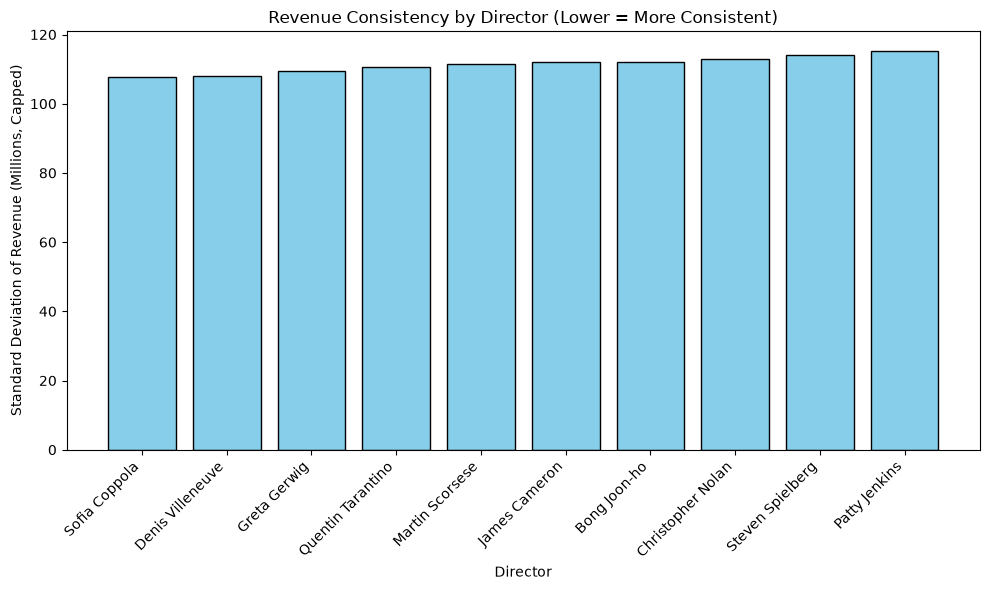

In [104]:
plt.figure(figsize=(10,6))
plt.bar(df_sorted["director"], df_sorted["std_revenue"], color="skyblue", edgecolor="black")
plt.xlabel("Director")
plt.ylabel("Standard Deviation of Revenue (Millions, Capped)")
plt.title("Revenue Consistency by Director (Lower = More Consistent)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Key Insight




The analysis shows that Patty Jenkins has the highest average movie revenue at 113.07, followed by Bong Joon-ho, Steven Spielberg, Christopher Nolan, and James Cameron, indicating strong commercial performance among these directors. However, Patty Jenkins also has the highest standard deviation (115.16), which means her movie revenues fluctuate considerably and therefore her high average does not necessarily indicate consistent success. On the other hand, Sofia Coppola has the lowest average revenue (106.48) and the lowest standard deviation (107.63), suggesting more stable but comparatively lower revenue performance. Overall, the relatively high standard deviations across all directors indicate that movie revenue varies substantially from film to film, so average revenue alone is not sufficient to determine consistency. Since the number of movies for each director is also nearly equal, the comparison is reasonably balanced. For a stronger business conclusion, the analysis should additionally measure the percentage of movies crossing a defined success threshold, which would better identify directors who consistently deliver successful movies.